Saving heart_diseases.csv to heart_diseases (1).csv
--- KNN (K=20) Model Evaluation ---
Training Accuracy: 0.8898
Testing Accuracy: 0.8474
Accuracy: 0.8474025974025974

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.79      0.84       159
           1       0.80      0.91      0.85       149

    accuracy                           0.85       308
   macro avg       0.85      0.85      0.85       308
weighted avg       0.85      0.85      0.85       308


Confusion Matrix:
 [[125  34]
 [ 13 136]]


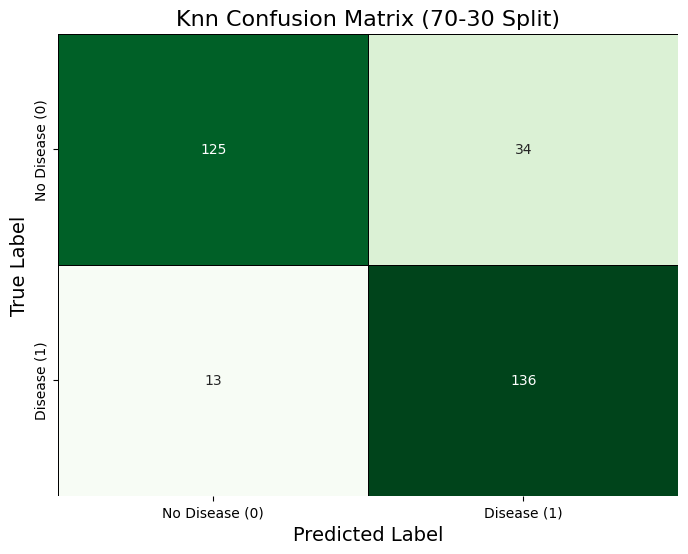

--- Naive Bayes Model Evaluation (70-30 Split) ---
Training Accuracy: 0.8521617852161785
Testing Accuracy: 0.814935064935065
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.74      0.81       159
           1       0.76      0.89      0.82       149

    accuracy                           0.81       308
   macro avg       0.82      0.82      0.81       308
weighted avg       0.82      0.81      0.81       308

Confusion Matrix:
 [[118  41]
 [ 16 133]]


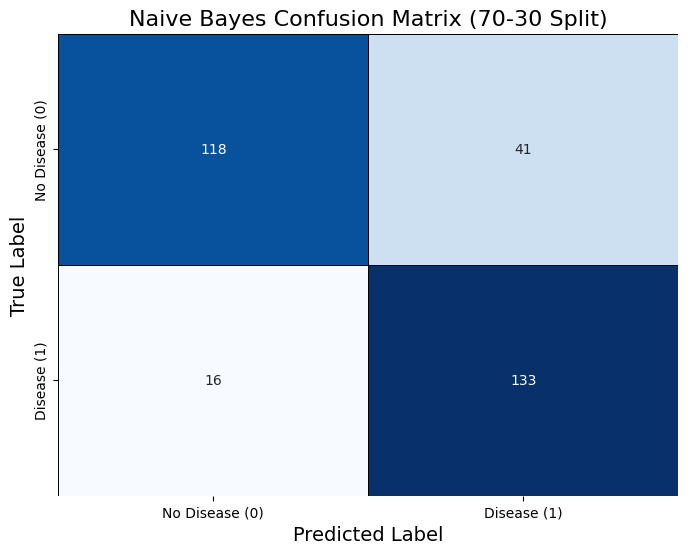

--- Decision Tree Model Evaluation (70-30 Split) ---
Training Accuracy: 0.8968
Testing Accuracy: 0.8344

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.76      0.83       159
           1       0.78      0.91      0.84       149

    accuracy                           0.83       308
   macro avg       0.84      0.84      0.83       308
weighted avg       0.84      0.83      0.83       308


Confusion Matrix:
 [[121  38]
 [ 13 136]]


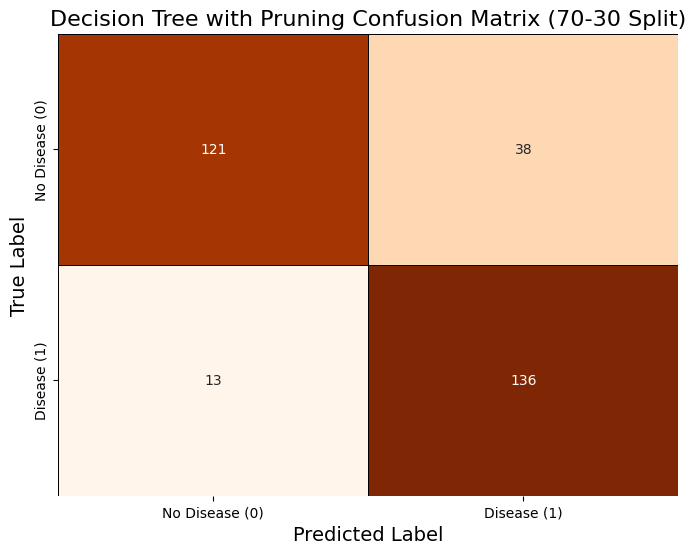

--- Logistic Regression Model Evaluation (70-30 Split) ---
Training Accuracy: 0.8688981868898187
Testing Accuracy: 0.8051948051948052

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80       159
           1       0.76      0.87      0.81       149

    accuracy                           0.81       308
   macro avg       0.81      0.81      0.80       308
weighted avg       0.81      0.81      0.80       308


Confusion Matrix:
 [[119  40]
 [ 20 129]]


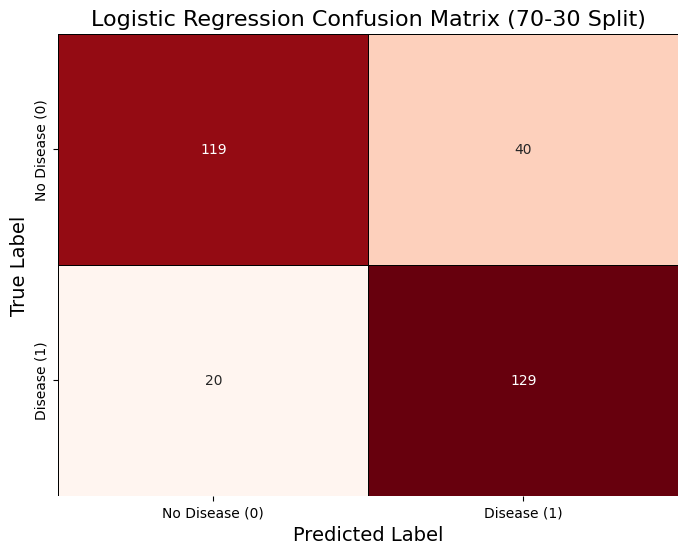

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


uploaded = files.upload()
filename = list(uploaded.keys())[0]
ds = pd.read_csv(filename)
ds = pd.read_csv('heart_diseases.csv')
# (I) Features (X) and Target (y)
X = ds.drop("target", axis=1)
y = ds["target"]

# (II) Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# (III) Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- KNN MODEL IMPLEMENTATION ---

# 1. K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=20)
knn_model.fit(X_train, y_train)

#  Make predictions on the training data
y_pred_train = knn_model.predict(X_train)

#  Calculate accuracy on the training data
train_accuracy = accuracy_score(y_train, y_pred_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

#  Evaluation
print("--- KNN (K=20) Model Evaluation ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


cm = confusion_matrix(y_test, y_pred_knn)

#  Create the Plot
plt.figure(figsize=(8, 6))

# Use Seaborn's heatmap function
sns.heatmap(
    cm,
    annot=True,              # Show the actual numbers in the cells
    fmt='d',                 # Format the numbers as integers ('d' for decimal)
    cmap='Greens',            # Use a color palette (e.g., 'Blues' or 'YlGnBu')
    cbar=False,              # Don't show the color bar on the side
    linewidths=0.5,          # Add lines between cells for clarity
    linecolor='black'
)

# 3. Add Labels and Title
plt.title('Knn Confusion Matrix (70-30 Split)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

# Set the tick labels (0 = No Disease, 1 = Disease)
plt.xticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=0)
plt.yticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=90)

plt.show()

# 2. Naive -Bayes model training
nb_classifier = GaussianNB()
nb_classifier.fit(X_train,y_train)

y_pred = nb_classifier.predict(X_test)
y_pred_train_nb = nb_classifier.predict(X_train)

print("--- Naive Bayes Model Evaluation (70-30 Split) ---")


train_accuracy_nb = accuracy_score(y_train, y_pred_train_nb)
test_accuracy_nb = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_accuracy_nb)
print("Testing Accuracy:", test_accuracy_nb)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

# Create the Plot
plt.figure(figsize=(8, 6))

# Use Seaborn's heatmap function
sns.heatmap(
    cm,
    annot=True,              # Show the actual numbers in the cells
    fmt='d',                 # Format the numbers as integers ('d' for decimal)
    cmap='Blues',            # Use a color palette (e.g., 'Blues' or 'YlGnBu')
    cbar=False,              # Don't show the color bar on the side
    linewidths=0.5,          # Add lines between cells for clarity
    linecolor='black'
)

# 3. Add Labels and Title
plt.title('Naive Bayes Confusion Matrix (70-30 Split)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

# Set the tick labels (0 = No Disease, 1 = Disease)
plt.xticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=0)
plt.yticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=90)

plt.show()



# 3.  MODEL TRAINING (Decision Tree with Pruning) ---
# Setting max_depth=4 to prevent the tree from memorizing the data

dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=4)
dt_classifier.fit(X_train,y_train)
y_pred=dt_classifier.predict(X_test)
y_pred_dt=dt_classifier.predict(X_train)


print("--- Decision Tree Model Evaluation (70-30 Split) ---")


train_accuracy_dt = accuracy_score(y_train, y_pred_dt)
test_accuracy_dt = accuracy_score(y_test, y_pred)
print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Testing Accuracy: {test_accuracy_dt:.4f}")

# Use the TEST predictions for the final report and matrix
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


cm_dt = confusion_matrix(y_test, y_pred)

#  Create the Plot
plt.figure(figsize=(8, 6))

# Use Seaborn's heatmap function
sns.heatmap(
    cm_dt,
    annot=True,              # Show the actual numbers in the cells
    fmt='d',                 # Format the numbers as integers ('d' for decimal)
    cmap='Oranges',            # Use a color palette (e.g., 'Blues' or 'YlGnBu')
    cbar=False,              # Don't show the color bar on the side
    linewidths=0.5,          # Add lines between cells for clarity
    linecolor='black'
)

# 3. Add Labels and Title
plt.title('Decision Tree with Pruning Confusion Matrix (70-30 Split)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

# Set the tick labels (0 = No Disease, 1 = Disease)
plt.xticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=0)
plt.yticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=90)

plt.show()





# 4. Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

#  Predictions on trained and tested data
y_pred = model.predict(X_train)
y_pred_lr = model.predict(X_test)


# Accuracy check...
train_accuracy = accuracy_score(y_train, y_pred)
test_accuracy = accuracy_score(y_test, y_pred_lr)


# Evaluation
print("--- Logistic Regression Model Evaluation (70-30 Split) ---")
print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))



cm = confusion_matrix(y_test, y_pred_lr)

# Create the Plot
plt.figure(figsize=(8, 6))

# Use Seaborn's heatmap function
sns.heatmap(
    cm,
    annot=True,              # Show the actual numbers in the cells
    fmt='d',                 # Format the numbers as integers ('d' for decimal)
    cmap='Reds',            # Use a color palette (e.g., 'Blues' or 'YlGnBu')
    cbar=False,              # Don't show the color bar on the side
    linewidths=0.5,          # Add lines between cells for clarity
    linecolor='black'
)

#  Add Labels and Title
plt.title('Logistic Regression Confusion Matrix (70-30 Split)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

# Set the tick labels (0 = No Disease, 1 = Disease)
plt.xticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=0)
plt.yticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'], rotation=90)

plt.show()





